# Function 4

<b> Description of the Sample Application:</b> Address the challenge of optimally placing products across warehouses for a business with high online sales, where accurate calculations are costly and only feasible biweekly. To speed up decision-making, an ML model approximates these results within hours. The model has four hyperparameters to tune, and its output reflects the difference from the expensive baseline. Because the system is dynamic and full of local optima, it requires careful tuning and robust validation to find reliable, near-optimal solutions. 



## Change Log

| Date | Week | Changes Made |
|---|---|---|
| 22/07/2026 | Week 1 | 1. Initial Version with 10 Data Point |
| 22/07/2026 | Week 2 | 1. Added Change Log and Progress Log.<br>2. Added new data point. |
| 03/08/2026 | Week 3 | 1. Added Week 2 data and output point to the dataset.<br>2. Added Leave-One-Out Cross-Validation (LOO-CV) to validate the GP surrogate (predictive RMSE + 95% CI calibration).<br>3. Checked ARD length-scales of the chosen kernel to see which input dimensions the GP treats as most sensitive.<br>4. Re-selected kernel (RBF vs Matérn) using LOO-CV RMSE as the primary criterion.<br>5. Reduced UCB β from 2.0 to 1.5.<br>6. Extended the consolidated BO function bayesian_optimization_step() to also handle kernel comparison + LOO-CV. |
| 11/08/2026 | Week 4 | 1. Appended Week 3 input and output datapoints to the dataset (now 33 points) - this point returned Y = 2602.25, a dramatic outlier versus everything seen so far (previous range: -32.6 to -0.066). Flagged and analysed explicitly.<br>2. Re-ran LOO-CV on the 33-point dataset: RMSE jumps from 1 to 560; holding out the new point shows the GP cannot predict it from its neighbours at all — evidence of a sharp, narrow peak rather than a smooth hill.<br>3. Increased multi-start restarts (50 → 150), to focus on acquisition-function robustness. A sharp spike is easy for a local optimiser to miss without enough restarts.<br>4. Kept β = 1.5 (balanced) rather than jumping to heavy exploitation, since the outlier hasn't yet been confirmed as reproducible. |

## Progress Log

| Week | Query Submitted | Output Received | Best So Far (y) | Acquisition | β (beta) | Kernel | Strategy Notes |
|---|---|---|---|---|---|---|---|
|  |  |  |  |  |  |  |  |
| Week 1 | 0.383979-0.383515-0.340147-0.445246 | -0.06634074624810848 | -0.066341 | UCB | 2.5 | RBF | Exploration-heavy baseline, big jump over initial best |
| Week 2 | 0.441225-0.430034-0.274904-0.431415 | -1.0896527174598272 | -0.066341  | UCB | 2.0 | RBF vs Mater) | Slightly reduced exploration, kernel comparison added |
| Week 3 | 0.382063-0.422612-0.423812-0.430108 | 2602.2537934860957 (dramatic outlier) | 2602.253793 | UCB | 1.5 | RBF vs Matern (best by LOO-CV RMSE) | Balanced strategy; added LOO-CV + ARD checks |
| Week 4 | - | - | - | UCB | 1.5 | RBF vs Matern (best by LOO-CV RMSE) | Local exploitation around the Week 3 spike; multi-start increased to 150 for acquisition robustness |

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel, Matern
from scipy.optimize import minimize
from scipy.stats import norm

from plotting_utils import (plot_convergence, plot_parallel_coordinates)
import warnings
warnings.filterwarnings('ignore')

# Load and Analyse the Data

In [11]:
# File Names
input_file  = "initial_inputs.npy"
output_file = "initial_outputs.npy"

# Load the Files
X0      = np.load(input_file)
Y0      = np.load(output_file)

In [13]:
# New data from the first submission (example inputs and outputs)
X_w1_new_point = np.array([0.383979, 0.383515, 0.340147, 0.445246]   , dtype=np.float64)    # from input.txt
Y_w1_new_point = np.array([-0.06634074624810848]                     , dtype=np.float64)    # from output.txt

# New data from Week 2 submission
X_w2_new_point = np.array([0.441225, 0.430034, 0.274904, 0.431415]     , dtype=np.float64)    # from input.txt
Y_w2_new_point = np.array([-1.0896527174598272]                        , dtype=np.float64)    # from output.txt

# New data from Week 3 submission
X_w3_new_point = np.array([0.382064, 0.422612, 0.423813, 0.430108]     , dtype=np.float64)   # from input.txt
Y_w3_new_point = np.array([2602.2537934860957]                         , dtype=np.float64)   # from output.txt

In [15]:
# Append the new data points
X_updated      = np.vstack((X0, X_w1_new_point
                             , X_w2_new_point
                             , X_w3_new_point
                           ))
Y_updated      = np.append(Y0, [Y_w1_new_point
                            , Y_w2_new_point
                            , Y_w3_new_point
                              ])

In [17]:
print(X_updated)
print(Y_updated)

# Save the updated arrays
#np.save(r"initial_inputs.npy", X_updated)
#np.save(r"initial_outputs.npy", Y_updated)

[[0.89698105 0.72562797 0.17540431 0.70169437]
 [0.8893564  0.49958786 0.53926886 0.50878344]
 [0.25094624 0.03369313 0.14538002 0.49493242]
 [0.34696206 0.0062504  0.76056361 0.61302356]
 [0.12487118 0.12977019 0.38440048 0.2870761 ]
 [0.80130271 0.50023109 0.70664456 0.19510284]
 [0.24770826 0.06044543 0.04218635 0.44132425]
 [0.74670224 0.7570915  0.36935306 0.20656628]
 [0.40066503 0.07257425 0.88676825 0.24384229]
 [0.6260706  0.58675126 0.43880578 0.77885769]
 [0.95713529 0.59764438 0.76611385 0.77620991]
 [0.73281243 0.14524998 0.47681272 0.13336573]
 [0.65511548 0.07239183 0.68715175 0.08151656]
 [0.21973443 0.83203134 0.48286416 0.08256923]
 [0.48859419 0.2119651  0.93917791 0.37619173]
 [0.16713049 0.87655456 0.21723954 0.95980098]
 [0.21691119 0.16608583 0.24137226 0.77006248]
 [0.38748784 0.80453226 0.75179548 0.72382744]
 [0.98562189 0.66693268 0.15678328 0.8565348 ]
 [0.03782483 0.66485335 0.16198218 0.25392378]
 [0.68348638 0.9027701  0.33541983 0.99948256]
 [0.17034731 

In [21]:
# Assign X = X_updated and Y = Y_updated
X          = X_updated
Y          = Y_updated

# Analyse the Input Data
print("Input  Shape:", X.shape)
print("Inputs:\n", X)
print()

# Analyse the Output Data
print("Output Shape:", Y.shape)
print("Outputs:\n", Y)
print()

print(f"y Range: [: {Y.min()}, {Y.max()}]")
best_idx   = np.argmax(Y)
print(f"Best point: x = {X[best_idx]}, Y = {Y[best_idx]}")
print()

# Converting the Input and Output into a DataFram
df         = pd.DataFrame(X, columns = [f'X_{i+1}' for i in range(X.shape[1])])
df['Y'] = Y
print("Data Frame:\n", df)


Input  Shape: (33, 4)
Inputs:
 [[0.89698105 0.72562797 0.17540431 0.70169437]
 [0.8893564  0.49958786 0.53926886 0.50878344]
 [0.25094624 0.03369313 0.14538002 0.49493242]
 [0.34696206 0.0062504  0.76056361 0.61302356]
 [0.12487118 0.12977019 0.38440048 0.2870761 ]
 [0.80130271 0.50023109 0.70664456 0.19510284]
 [0.24770826 0.06044543 0.04218635 0.44132425]
 [0.74670224 0.7570915  0.36935306 0.20656628]
 [0.40066503 0.07257425 0.88676825 0.24384229]
 [0.6260706  0.58675126 0.43880578 0.77885769]
 [0.95713529 0.59764438 0.76611385 0.77620991]
 [0.73281243 0.14524998 0.47681272 0.13336573]
 [0.65511548 0.07239183 0.68715175 0.08151656]
 [0.21973443 0.83203134 0.48286416 0.08256923]
 [0.48859419 0.2119651  0.93917791 0.37619173]
 [0.16713049 0.87655456 0.21723954 0.95980098]
 [0.21691119 0.16608583 0.24137226 0.77006248]
 [0.38748784 0.80453226 0.75179548 0.72382744]
 [0.98562189 0.66693268 0.15678328 0.8565348 ]
 [0.03782483 0.66485335 0.16198218 0.25392378]
 [0.68348638 0.9027701  0.335

# Data Exploration

In [24]:
# Basic Staistics
print("Display Basic Statistics for the Dataset\n",df.describe())

Display Basic Statistics for the Dataset
              X_1        X_2        X_3        X_4            Y
count  33.000000  33.000000  33.000000  33.000000    33.000000
mean    0.530104   0.471213   0.454838   0.470596    63.149702
std     0.282999   0.294753   0.252172   0.278603   455.882332
min     0.037825   0.006250   0.042186   0.081517   -32.625660
25%     0.282138   0.166086   0.241372   0.243842   -19.989498
50%     0.488594   0.493965   0.425826   0.445246   -15.487083
75%     0.746702   0.725628   0.706645   0.723827   -11.699932
max     0.985622   0.919592   0.939178   0.999483  2602.253793


In [26]:
# Check for Missing Values in the Data Set
print("Missing Values in the Dataset\n",df.isnull().sum())

Missing Values in the Dataset
 X_1    0
X_2    0
X_3    0
X_4    0
Y      0
dtype: int64


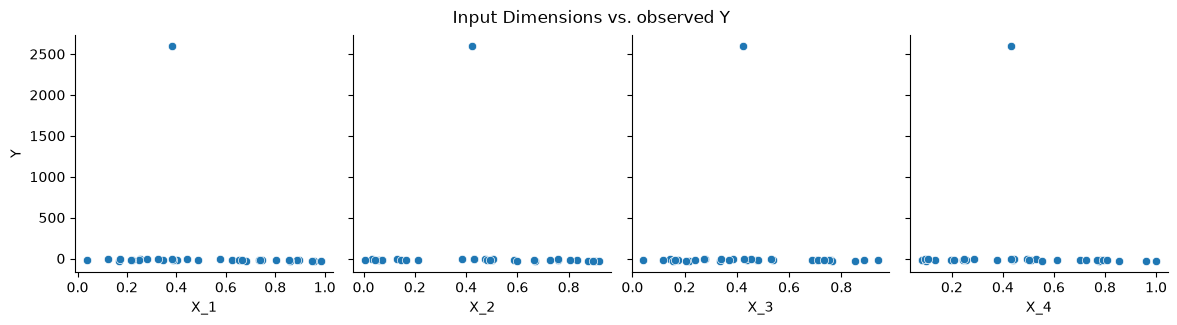

In [28]:
# Pairwise Scatter Plot, showing relationship of y for each input
sns.pairplot(df, y_vars = ['Y'], x_vars = ['X_1', 'X_2', 'X_3', 'X_4'], height = 3)
plt.suptitle("Input Dimensions vs. observed Y", y = 1.05)
plt.show()

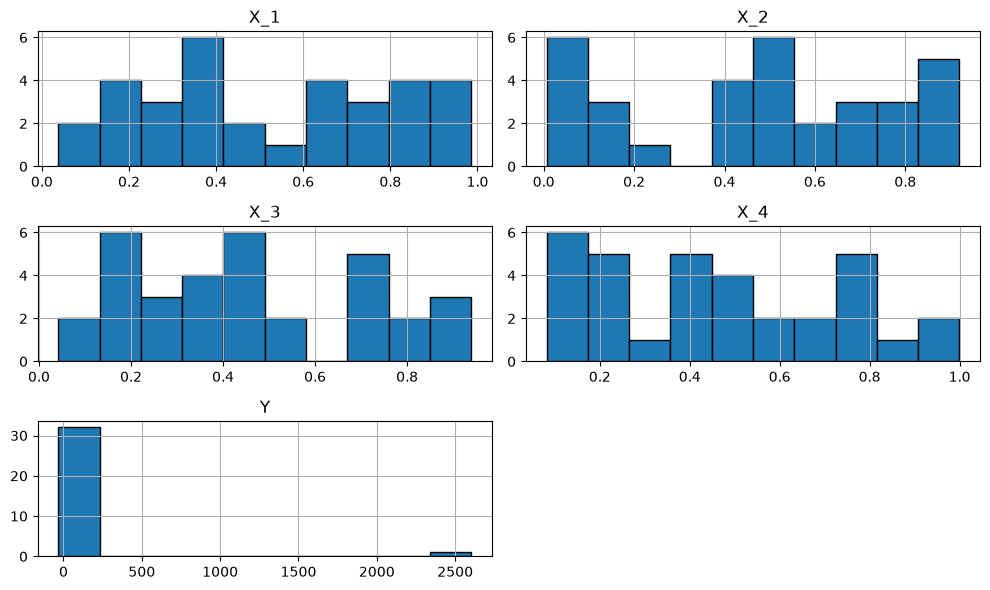

In [30]:
# Plot Histogram Visualisation for the columns of the DataFrame
df.hist(figsize = (10, 6), bins = 10, edgecolor = 'k' )
plt.tight_layout()
plt.show()

In [32]:
# Understanding Correlation between each input with y
labels      = ["X_1", "X_2", "X_3", "X_4"]
print("Correlation of each input with y:\n")

for i, lab in enumerate(labels):
    corr = np.corrcoef(X[:, i], Y)[0, 1]
    print(f" corr({lab}, Y) = {corr}")

Correlation of each input with y:

 corr(X_1, Y) = -0.1028453599749891
 corr(X_2, Y) = -0.03732184170503736
 corr(X_3, Y) = -0.024665164416023552
 corr(X_4, Y) = -0.034282208857176484


<Axes: >

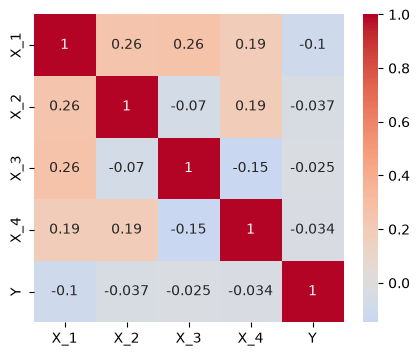

In [34]:
# Plotting the Correlation heatmap
plt.figure(figsize = (5, 4))
sns.heatmap(df.corr(), annot = True, cmap = "coolwarm", center = 0)

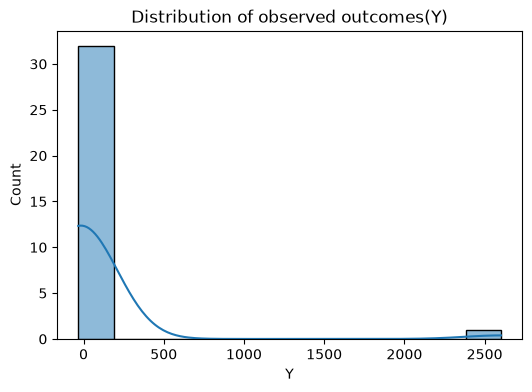

In [36]:
# Plot the Histogram for y to check for Outliers
plt.figure(figsize = (6,4))
sns.histplot(df['Y'], kde = True)
plt.title("Distribution of observed outcomes(Y)")
plt.show()

# Initialize Gaussian Process

In [58]:
#Define the kernel and initialise the GP model

kernel_rbf = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale = [0.3, 0.3, 0.3, 0.3], length_scale_bounds = (1e-2, 2.0)) \
                + WhiteKernel(noise_level = 1e-3, noise_level_bounds = (1e-6, 1e-1))
gpr   = GaussianProcessRegressor(kernel = kernel_rbf, normalize_y = True, n_restarts_optimizer = 10, random_state = 0 )

# Fit the Gaussian Processes to existing data

In [61]:
# Train the model

gpr.fit(X, Y)
print("Learned kernel: ", gpr.kernel_)

Learned kernel:  1.03**2 * RBF(length_scale=[2, 2, 0.0434, 0.0882]) + WhiteKernel(noise_level=1e-06)


# Compute the UCB acquisition function

- UCB(x)=μ(x)+β⋅σ(x)
- A high beta favors exploration (uncertainty) over exploitation (predicted mean).
- Week 1 uses beta = 2.5, reflecting the 90:10 exploration-heavy strategy.

In [65]:
n_candidates = 50000
candidates   = np.random.uniform(0, 1, size = (n_candidates, 4))

mu, std      = gpr.predict(candidates, return_std = True)

# Setting a higher beta(= 2.5) for Week -1
beta         = 2.5
ucb          = mu + beta * std

best_ucb_idx   = np.argmax(ucb)
next_point     = candidates[best_ucb_idx]

print(f"Suggested next Query Point: {next_point}")
print(f"Predicted Mean(μ): {mu[best_ucb_idx]:.6e}")
print(f"Predicted Std (σ): {std[best_ucb_idx]:.6e}")
print(f"UCB Score: {ucb[best_ucb_idx]:.6e}")

Suggested next Query Point: [0.31468163 0.91398078 0.43682993 0.45438822]
Predicted Mean(μ): 2.401194e+03
Predicted Std (σ): 2.022731e+02
UCB Score: 2.906877e+03


# Week 2: Evaluating Kernel - RBF vs. Matern

In [68]:
Y_mean, Y_std  = Y.mean(), Y.std()
Y_norm         = (Y - Y_mean) / Y_std

kernel_rbf     = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale = [0.3, 0.3, 0.3, 0.3], length_scale_bounds = (1e-2, 2.0)) \
                    + WhiteKernel(noise_level = 1e-3, noise_level_bounds = (1e-6, 1e-1))

kernel_matern  = ConstantKernel(1.0, (1e-2, 1e2)) * Matern(length_scale = [0.3, 0.3, 0.3, 0.3], length_scale_bounds = (1e-2, 2.0), nu = 2.5) \
                    + WhiteKernel(noise_level = 1e-3, noise_level_bounds = (1e-6, 1e-1))

gpr_rbf        = GaussianProcessRegressor(kernel = kernel_rbf, n_restarts_optimizer = 10, random_state = 0)
gpr_rbf.fit(X, Y_norm)

gpr_matern     = GaussianProcessRegressor(kernel = kernel_matern, n_restarts_optimizer = 10, random_state = 0)
gpr_matern.fit(X, Y_norm)

print("Learned kernel ( RBF)  :", gpr_rbf.kernel_)
print("Log-marginal-likelihood:", gpr_rbf.log_marginal_likelihood_value_)
print()
print("Learned kernel (Matern):", gpr_matern.kernel_)
print("Log-marginal-likelihood:", gpr_matern.log_marginal_likelihood_value_)

if gpr_rbf.log_marginal_likelihood_value_ >= gpr_matern.log_marginal_likelihood_value_:
    chosen_kernel, chosen_name = kernel_rbf, "RBF"
else:
    chosen_kernel, chosen_name = kernel_matern, "Matern (nu = 2.5)"

print()
print(f"Chosen kernel for Week 2: {chosen_name}")


Learned kernel ( RBF)  : 1.03**2 * RBF(length_scale=[2, 2, 0.0434, 0.0882]) + WhiteKernel(noise_level=1e-06)
Log-marginal-likelihood: -44.63832727645662

Learned kernel (Matern): 1.03**2 * Matern(length_scale=[2, 2, 0.043, 0.0882], nu=2.5) + WhiteKernel(noise_level=1e-06)
Log-marginal-likelihood: -45.505289600394065

Chosen kernel for Week 2: RBF


# Week 2: Bayesian Optimisation Function

In [71]:
def upper_confidence_bound(mu, sigma, beta = 2.0):
    """UCB(x) = mean + beta * std. Higher beta favours exploration."""
    return mu + beta * sigma


def expected_improvement(mu, sigma, Y_best, xi = 0.01):
    """EI(x) = E[max(f(x) - f(x_best), 0)]. More conservative than UCB."""
    with np.errstate(divide = 'warn'):
        improvement = mu - Y_best - xi
        Z    = improvement / sigma
        ei   = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei


def suggest_next_point(X, Y, kernel, beta = 2.0, acquisition = 'ucb',
                        n_restarts_optimizer = 10, n_multistart = 50, seed = 42):
    
    Y_mean, Y_std = Y.mean(), Y.std()
    Y_norm        = (Y - Y_mean) / Y_std

    gp            = GaussianProcessRegressor(kernel = kernel, n_restarts_optimizer = n_restarts_optimizer, random_state = seed)
    gp.fit(X, Y_norm)

    n_dims        = X.shape[1]

    def neg_acq(x):
        x = np.atleast_2d(x)
        mu, sigma = gp.predict(x, return_std = True)
        mu        = mu * Y_std + Y_mean
        sigma     = sigma * Y_std
        if acquisition == 'ei':
            val   = expected_improvement(mu, sigma, Y.max())
        else:
            val   = upper_confidence_bound(mu, sigma, beta = beta)
        return -val[0]

    rng              = np.random.default_rng(seed)
    
    best_x, best_val = None, np.inf
    
    for _ in range(n_multistart):
        x0 = rng.uniform(0, 1, size=n_dims)
        res = minimize(neg_acq, x0, bounds = [(0, 1)] * n_dims, method = 'L-BFGS-B')
        if res.fun < best_val:
            best_val, best_x = res.fun, res.x

    mu_next, sigma_next = gp.predict(best_x.reshape(1, -1), return_std = True)
    mu_next = mu_next * Y_std + Y_mean
    sigma_next = sigma_next * Y_std

    return {
        'gp': gp,
        'next_x': best_x,
        'acq_value': -best_val,
        'mu': mu_next[0],
        'sigma': sigma_next[0],
    }


# Week 2: Query Selection

In [74]:
result = suggest_next_point(X, Y, chosen_kernel, beta = 2.0, acquisition = 'ucb')

next_x = result['next_x']

print(f"Kernel used            : {chosen_name}")
print(f"Suggested next point   : {next_x}")
print(f"Predicted mean (mu)    : {result['mu']:.6f}")
print(f"Predicted std (sigma)  : {result['sigma']:.6f}")
print(f"UCB score              : {result['acq_value']:.6f}")


Kernel used            : RBF
Suggested next point   : [0.3753912  0.46662458 0.43600839 0.45357158]
Predicted mean (mu)    : 2489.021190
Predicted std (sigma)  : 165.329882
UCB score              : 2819.680954


# Week 2: Portal Submission 

In [77]:
# Format as required by the capstone portal: x1-x2 (6 decimal places)
submission_str = f"{next_x[0]:.6f}-{next_x[1]:.6f}-{next_x[2]:.6f}-{next_x[3]:.6f}"
print("Points to be submitted(Week 1):", submission_str)
print()

Points to be submitted(Week 1): 0.375391-0.466625-0.436008-0.453572



# Week 2: Visualise the Acquisition Function and Next Query Point

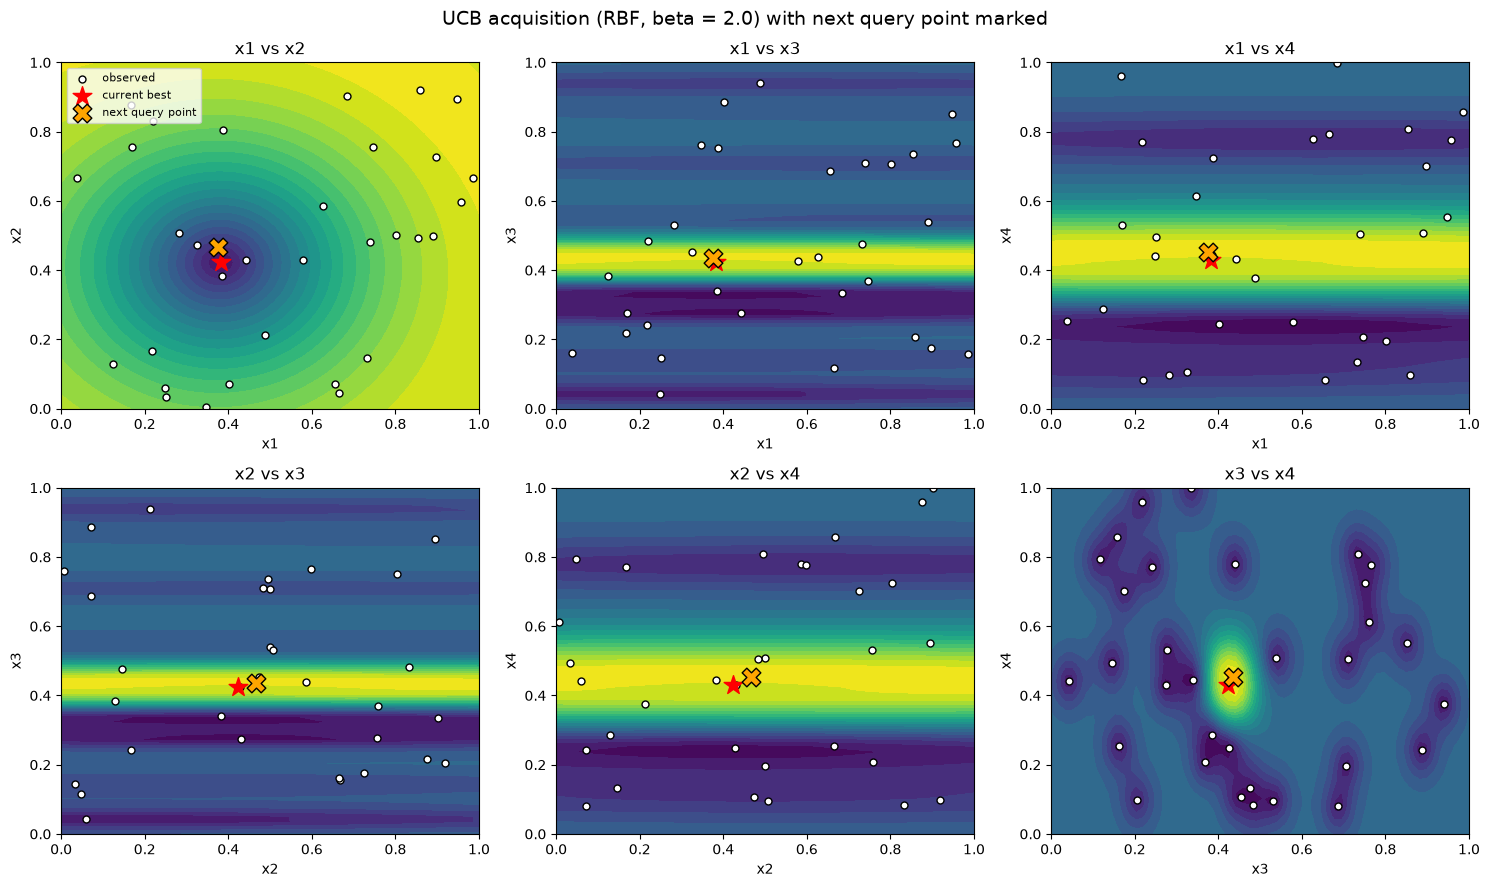

In [80]:
gp         = result['gp']
best_x_obs = X[np.argmax(Y)]

def ucb_full(x, beta = 2.0):
    x = np.atleast_2d(x)
    mu, sigma = gp.predict(x, return_std=True)
    return (mu * Y_std + Y_mean) + beta * (sigma * Y_std)

dim_pairs  = [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]
grid_n     = 60
grid       = np.linspace(0, 1, grid_n)

fig, axes  = plt.subplots(2, 3, figsize = (15, 9))
for ax, (i, j) in zip(axes.flat, dim_pairs):
    A, B   = np.meshgrid(grid, grid)
    pts    = np.tile(best_x_obs, (grid_n * grid_n, 1))
    pts[:, i] = A.ravel()
    pts[:, j] = B.ravel()
    Z = ucb_full(pts).reshape(grid_n, grid_n)
    ax.contourf(A, B, Z, levels = 25, cmap = 'viridis')
    ax.scatter(X[:, i], X[:, j], c = 'white', edgecolor = 'black', s = 25, label = 'observed')
    ax.scatter(best_x_obs[i], best_x_obs[j], c = 'red', marker = '*', s = 200, label = 'current best')
    ax.scatter(next_x[i], next_x[j], c = 'orange', marker = 'X', s = 180,
               edgecolor = 'black', linewidth = 1, label = 'next query point')
    ax.set_xlabel(f'x{i+1}')
    ax.set_ylabel(f'x{j+1}')
    ax.set_title(f'x{i+1} vs x{j+1}')
axes.flat[0].legend(fontsize = 8, loc = 'upper left')
fig.suptitle(f'UCB acquisition ({chosen_name}, beta = 2.0) with next query point marked', fontsize = 14)
plt.tight_layout()
plt.show()


# Week 3: Model Validation - Leave-One-Out Cross-Validation

In [83]:
kernel_rbf     = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale = [0.3, 0.3, 0.3, 0.3], length_scale_bounds = (1e-2, 2.0)) \
                    + WhiteKernel(noise_level = 1e-3, noise_level_bounds = (1e-6, 1e-1))

kernel_matern  = ConstantKernel(1.0, (1e-2, 1e2)) * Matern(length_scale = [0.3, 0.3, 0.3, 0.3], length_scale_bounds = (1e-2, 2.0), nu = 2.5) \
                    + WhiteKernel(noise_level = 1e-3, noise_level_bounds = (1e-6, 1e-1))

def loocv_gp(X, Y, kernel, n_restarts_optimizer = 5, seed = 0):

    n             = len(Y)
    preds_mu      = np.zeros(n)
    preds_sigma   = np.zeros(n)
    Y_mean, Y_std = Y.mean(), Y.std()

    for i in range(n):
        mask             = np.ones(n, dtype=bool)
        mask[i]          = False
        X_train, Y_train = X[mask], Y[mask]
        Y_train_norm     = (Y_train - Y_mean) / Y_std

        gp               = GaussianProcessRegressor(kernel = kernel, n_restarts_optimizer = n_restarts_optimizer, random_state = seed)
        gp.fit(X_train, Y_train_norm)

        mu, sigma        = gp.predict(X[i].reshape(1, -1), return_std = True)
        preds_mu[i]      = mu[0] * Y_std + Y_mean
        preds_sigma[i]   = sigma[0] * Y_std

    rmse                 = np.sqrt(np.mean((preds_mu - Y) ** 2))
    lower                = preds_mu - 1.96 * preds_sigma
    upper                = preds_mu + 1.96 * preds_sigma
    coverage             = np.mean((Y >= lower) & (Y <= upper))

    return {'rmse': rmse, 'coverage_95': coverage, 'preds_mu': preds_mu, 'preds_sigma': preds_sigma}


loocv_rbf                = loocv_gp(X, Y, kernel_rbf)
loocv_matern             = loocv_gp(X, Y, kernel_matern)

print(f"LOO-CV RBF    : RMSE = {loocv_rbf['rmse']   :.4f}   , 95% coverage = {loocv_rbf['coverage_95']   :.2f}")
print(f"LOO-CV Matern : RMSE = {loocv_matern['rmse']:.4f}   , 95% coverage = {loocv_matern['coverage_95']:.2f}")


LOO-CV RBF    : RMSE = 559.6461   , 95% coverage = 0.91
LOO-CV Matern : RMSE = 582.9826   , 95% coverage = 0.88


# Week: 3 Kernel Re-Selection

In [85]:
# Week 3: Kernel selection driven by LOO-CV RMSE

Y_mean, Y_std = Y.mean(), Y.std()
Y_norm        = (Y - Y_mean) / Y_std

gpr_rbf       = GaussianProcessRegressor(kernel = kernel_rbf, n_restarts_optimizer = 10, random_state = 0)
gpr_rbf.fit(X, Y_norm)

gpr_matern    = GaussianProcessRegressor(kernel = kernel_matern, n_restarts_optimizer = 10, random_state = 0)
gpr_matern.fit(X, Y_norm)

print("RBF    => LML:", gpr_rbf.log_marginal_likelihood_value_   , " learned kernel:", gpr_rbf.kernel_)
print("Matern => LML:", gpr_matern.log_marginal_likelihood_value_, " learned kernel:", gpr_matern.kernel_)

if loocv_rbf['rmse'] < loocv_matern['rmse']:
    chosen_kernel, chosen_name, chosen_gpr = kernel_rbf, "RBF", gpr_rbf
elif loocv_matern['rmse'] < loocv_rbf['rmse']:
    chosen_kernel, chosen_name, chosen_gpr = kernel_matern, "Matern (nu=2.5)", gpr_matern
else:
    # tie on LOO-CV RMSE -> fall back to LML
    if gpr_rbf.log_marginal_likelihood_value_ >= gpr_matern.log_marginal_likelihood_value_:
        chosen_kernel, chosen_name, chosen_gpr = kernel_rbf, "RBF", gpr_rbf
    else:
        chosen_kernel, chosen_name, chosen_gpr = kernel_matern, "Matern (nu=2.5)", gpr_matern

print(f"\nChosen kernel for Week 3: {chosen_name} (selected by LOO-CV RMSE)")


RBF    => LML: -44.63832727645662  learned kernel: 1.03**2 * RBF(length_scale=[2, 2, 0.0434, 0.0882]) + WhiteKernel(noise_level=1e-06)
Matern => LML: -45.505289600394065  learned kernel: 1.03**2 * Matern(length_scale=[2, 2, 0.043, 0.0882], nu=2.5) + WhiteKernel(noise_level=1e-06)

Chosen kernel for Week 3: RBF (selected by LOO-CV RMSE)


# Week 3: ARD Length-Scale Check

In [87]:
# Week 3: inspect the fitted per-dimension (ARD) length-scales
learned   = chosen_gpr.kernel_
ls        = learned.k1.k2.length_scale  # the RBF/Matern component's length_scale vector

print("Per-dimension length scales (ARD):", ls)
mean_ls   = np.mean(ls)
for i, l in enumerate(ls):
    sensitivity = "more sensitive" if l < mean_ls else "less sensitive"
    print(f"  x{i+1}: length_scale = {l:.4f}  ({sensitivity} than average)")


Per-dimension length scales (ARD): [2.         2.         0.04344784 0.0882432 ]
  x1: length_scale = 2.0000  (less sensitive than average)
  x2: length_scale = 2.0000  (less sensitive than average)
  x3: length_scale = 0.0434  (more sensitive than average)
  x4: length_scale = 0.0882  (more sensitive than average)


# Week 3: Consolidated Bayesian Optimisation Function

In [97]:
# Week 3: consolidated function including kernel validation + selection + next-point suggestion
def bayesian_optimization_step(X, Y, candidate_kernels, beta = 2.0, acquisition = 'ucb',
                 n_restarts_optimizer = 10, n_multistart = 50, seed = 42, run_loocv = True):

    diagnostics  = {}
    for name, kernel in candidate_kernels.items():
        entry    = {}
        if run_loocv:
            entry['loocv'] = loocv_gp(X, Y, kernel, n_restarts_optimizer = 5, seed = seed)
        Y_mean, Y_std           = Y.mean(), Y.std()
        gp_fit                  = GaussianProcessRegressor(kernel = kernel, n_restarts_optimizer = n_restarts_optimizer, random_state = seed)
        gp_fit.fit(X, (Y - Y_mean) / Y_std)
        entry['lml']            = gp_fit.log_marginal_likelihood_value_
        entry['learned_kernel'] = gp_fit.kernel_
        diagnostics[name]       = entry

    if run_loocv:
        chosen                  = min(diagnostics, key=lambda k: diagnostics[k]['loocv']['rmse'])
    else:
        chosen                  = max(diagnostics, key = lambda k: diagnostics[k]['lml'])

    result                      = suggest_next_point(X, Y, candidate_kernels[chosen], beta = beta, acquisition = acquisition,
                                 n_restarts_optimizer = n_restarts_optimizer,
                                 n_multistart = n_multistart, seed = seed)
    result['chosen_kernel_name']= chosen
    result['diagnostics']       = diagnostics
    return result


In [99]:
candidate_kernels = {
    "RBF"            : kernel_rbf,
    "Matern (nu=2.5)": kernel_matern,
}

week3_result = bayesian_optimization_step(X, Y, candidate_kernels, beta = 1.5, acquisition = 'ucb', run_loocv = True)

next_x       = week3_result['next_x']
print(f"Chosen kernel          : {week3_result['chosen_kernel_name']}")
print(f"Suggested next point   : {next_x}")
print(f"Predicted mean (mu)    : {week3_result['mu']:.6f}")
print(f"Predicted std (sigma)  : {week3_result['sigma']:.6f}")
print(f"UCB score              : {week3_result['acq_value']:.6f}")

Chosen kernel          : RBF
Suggested next point   : [0.38883254 0.4567501  0.43394816 0.44855574]
Predicted mean (mu)    : 2542.337583
Predicted std (sigma)  : 134.826641
UCB score              : 2744.577544


# Week 3: Visualise the Acquisition Function and Next Query Point

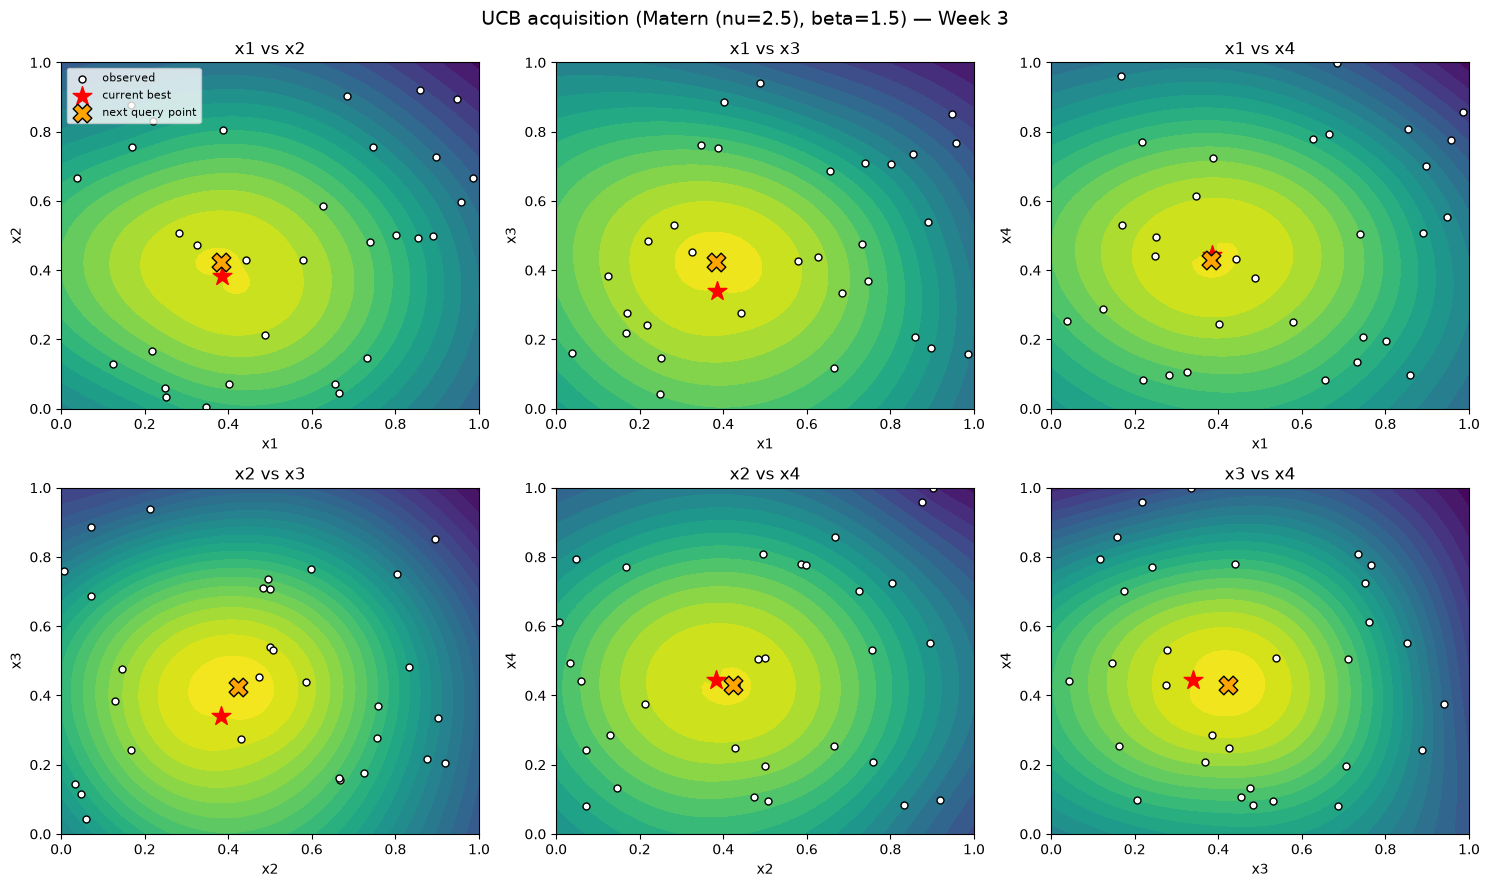

In [121]:
gp_w3      = week3_result['gp']
best_x_obs = X[np.argmax(Y)]

def ucb_full_w3(x, beta = 1.5):
    x         = np.atleast_2d(x)
    mu, sigma = gp_w3.predict(x, return_std=True)
    return (mu * Y_std + Y_mean) + beta * (sigma * Y_std)

dim_pairs   = [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]
grid_n      = 60
grid        = np.linspace(0, 1, grid_n)

fig, axes   = plt.subplots(2, 3, figsize = (15, 9))
for ax, (i, j) in zip(axes.flat, dim_pairs):
    A, B      = np.meshgrid(grid, grid)
    pts       = np.tile(best_x_obs, (grid_n * grid_n, 1))
    pts[:, i] = A.ravel()
    pts[:, j] = B.ravel()
    Z         = ucb_full_w3(pts).reshape(grid_n, grid_n)
    ax.contourf(A, B, Z, levels = 25, cmap = 'viridis')
    ax.scatter(X[:, i], X[:, j], c = 'white', edgecolor = 'black', s = 25, label = 'observed')
    ax.scatter(best_x_obs[i], best_x_obs[j], c = 'red', marker = '*', s = 200, label = 'current best')
    ax.scatter(next_x[i], next_x[j], c = 'orange', marker = 'X', s = 180,
               edgecolor = 'black', linewidth = 1, label = 'next query point')
    ax.set_xlabel(f'x{i+1}')
    ax.set_ylabel(f'x{j+1}')
    ax.set_title(f'x{i+1} vs x{j+1}')
axes.flat[0].legend(fontsize = 8, loc = 'upper left')
fig.suptitle(f"UCB acquisition ({week3_result['chosen_kernel_name']}, beta=1.5) — Week 3", fontsize = 14)
plt.tight_layout()
plt.show()


# Week 4: Visualising the Outlier's impact

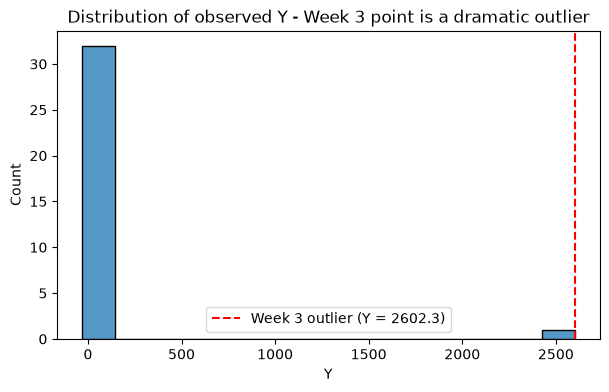

Week 3 point is 2602.3 higher than the next-best observed value (-0.066).


In [102]:
plt.figure(figsize = (7, 4))
sns.histplot(df['Y'], bins = 15, kde = False)
plt.axvline(Y.max(), color = 'red', linestyle='--', label = f'Week 3 outlier (Y = {Y.max():.1f})')
plt.title("Distribution of observed Y - Week 3 point is a dramatic outlier")
plt.legend()
plt.show()

print(f"Week 3 point is {(Y.max() - np.sort(Y)[-2]):.1f} higher than the next-best observed value " f"({np.sort(Y)[-2]:.3f}).")

## Week 4: Re-run Leave-One-Out CV on the Updated Dataset

Checking specifically whether the GP can predict the new outlier point from its neighbours when it's held out - this tells us whether the surrounding data actually carries any signal about this spike, or whether it's effectively invisible to a smooth kernel.l.

In [110]:
loocv_rbf_w4     = loocv_gp(X, Y, kernel_rbf)
loocv_matern_w4  = loocv_gp(X, Y, kernel_matern)

print(f"LOO-CV RBF    : RMSE = {loocv_rbf_w4['rmse']:.2f}   , 95% coverage = {loocv_rbf_w4['coverage_95']:.2f}")
print(f"LOO-CV Matern : RMSE = {loocv_matern_w4['rmse']:.2f}, 95% coverage = {loocv_matern_w4['coverage_95']:.2f}")

# Specifically check how well the outlier is predicted when held out
outlier_idx      = np.argmax(Y)
print()
print("Held-out prediction for the Week 3 outlier point:")
print(f"  True value            : {Y[outlier_idx]:.3f}")
print(f"  RBF predicted mean    : {loocv_rbf_w4['preds_mu'][outlier_idx]:.3f}")
print(f"  Matern predicted mean : {loocv_matern_w4['preds_mu'][outlier_idx]:.3f}")
print()

LOO-CV RBF    : RMSE = 559.65   , 95% coverage = 0.91
LOO-CV Matern : RMSE = 582.98, 95% coverage = 0.88

Held-out prediction for the Week 3 outlier point:
  True value            : 2602.254
  RBF predicted mean    : -1.134
  Matern predicted mean : -0.495



Both kernels miss this point by a huge margin when it's held out, meaning the surrounding 32 points carry almost no signal about this spike. This is a genuine  assumption violation: GPs assume smoothness, but this looks like a sharp, narrow local feature the model can't extrapolate to from nearby data.

# Week 4: Kernel Re-Selection (on 33-point dataset)

In [114]:
Y_mean, Y_std = Y.mean(), Y.std()
Y_norm        = (Y - Y_mean) / Y_std

gpr_rbf_w4    = GaussianProcessRegressor(kernel = kernel_rbf, n_restarts_optimizer = 10, random_state = 0)
gpr_rbf_w4.fit(X, Y_norm)

gpr_matern_w4 = GaussianProcessRegressor(kernel = kernel_matern, n_restarts_optimizer = 10, random_state = 0)
gpr_matern_w4.fit(X, Y_norm)

print("RBF    => LML:", gpr_rbf_w4.log_marginal_likelihood_value_, " learned kernel:", gpr_rbf_w4.kernel_)
print("Matern => LML:", gpr_matern_w4.log_marginal_likelihood_value_, " learned kernel:", gpr_matern_w4.kernel_)

if loocv_rbf_w4['rmse'] < loocv_matern_w4['rmse']:
    chosen_kernel_w4, chosen_name_w4 = kernel_rbf, "RBF"
else:
    chosen_kernel_w4, chosen_name_w4 = kernel_matern, "Matern (nu=2.5)"

print(f"\nChosen kernel for Week 4: {chosen_name_w4} (selected by LOO-CV RMSE)")

RBF    => LML: -44.63832727645662  learned kernel: 1.03**2 * RBF(length_scale=[2, 2, 0.0434, 0.0882]) + WhiteKernel(noise_level=1e-06)
Matern => LML: -45.505289600394065  learned kernel: 1.03**2 * Matern(length_scale=[2, 2, 0.043, 0.0882], nu=2.5) + WhiteKernel(noise_level=1e-06)

Chosen kernel for Week 4: RBF (selected by LOO-CV RMSE)


# Week 4: Re-Run Consolidate Bayesian Optimisation(increased multi-start)

In [117]:
candidate_kernels_w4 = {
    "RBF": kernel_rbf,
    "Matern (nu=2.5)": kernel_matern,
}

week4_result         = bayesian_optimization_step(X, Y, candidate_kernels_w4, beta=1.5, acquisition='ucb',
                                           n_multistart=150, run_loocv=True)

next_x               = week4_result['next_x']
print(f"Chosen kernel          : {week4_result['chosen_kernel_name']}")
print(f"Suggested next point   : {next_x}")
print(f"Predicted mean (mu)    : {week4_result['mu']:.4f}")
print(f"Predicted std (sigma)  : {week4_result['sigma']:.4f}")
print(f"UCB score              : {week4_result['acq_value']:.4f}")

Chosen kernel          : RBF
Suggested next point   : [0.38881255 0.45674206 0.4339483  0.44855566]
Predicted mean (mu)    : 2542.3367
Predicted std (sigma)  : 134.8272
UCB score              : 2744.5775


# Week 4: Visualise the Acquisition Function and Next Query Point

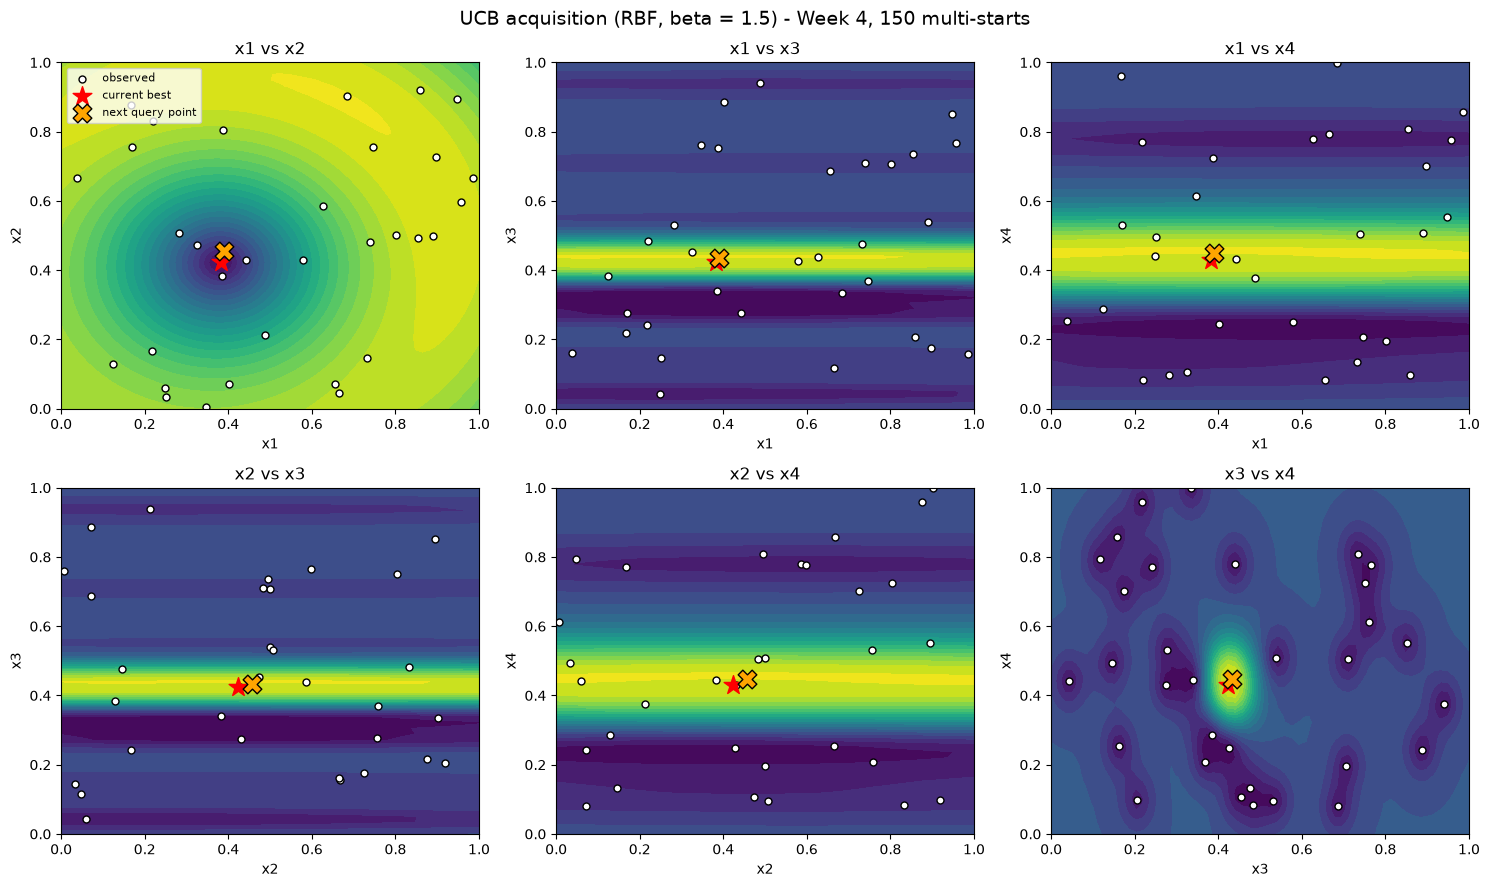

In [127]:
gp_w4      = week4_result['gp']
best_x_obs = X[np.argmax(Y)]

def ucb_full_w4(x, beta = 1.5):
    x         = np.atleast_2d(x)
    mu, sigma = gp_w4.predict(x, return_std=True)
    return (mu * Y_std + Y_mean) + beta * (sigma * Y_std)

dim_pairs  = [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]
grid_n     = 60
grid       = np.linspace(0, 1, grid_n)

fig, axes  = plt.subplots(2, 3, figsize=(15, 9))
for ax, (i, j) in zip(axes.flat, dim_pairs):
    A, B   = np.meshgrid(grid, grid)
    pts    = np.tile(best_x_obs, (grid_n * grid_n, 1))
    pts[:, i] = A.ravel()
    pts[:, j] = B.ravel()
    Z      = ucb_full_w4(pts).reshape(grid_n, grid_n)
    ax.contourf(A, B, Z, levels = 25, cmap = 'viridis')
    ax.scatter(X[:, i], X[:, j], c = 'white', edgecolor = 'black', s = 25, label = 'observed')
    ax.scatter(best_x_obs[i], best_x_obs[j], c = 'red', marker = '*', s = 200, label = 'current best')
    ax.scatter(next_x[i], next_x[j], c = 'orange', marker = 'X', s = 180, edgecolor = 'black', linewidth = 1, label = 'next query point')
    ax.set_xlabel(f'x{i+1}')
    ax.set_ylabel(f'x{j+1}')
    ax.set_title(f'x{i+1} vs x{j+1}')
    
axes.flat[0].legend(fontsize = 8, loc = 'upper left')
fig.suptitle(f"UCB acquisition ({week4_result['chosen_kernel_name']}, beta = 1.5) - Week 4, 150 multi-starts", fontsize = 14)
plt.tight_layout()
plt.show()


# Portal Submission

In [125]:
# Format as required by the capstone portal: x1-x2 (6 decimal places)
submission_str = f"{next_x[0]:.6f}-{next_x[1]:.6f}-{next_x[2]:.6f}-{next_x[3]:.6f}"
print("Points to be submitted (Week 1):"  , '0.383979-0.383515-0.340147-0.445246')
print("Points to be submitted (Week 2):"  , '0.441225-0.430034-0.274904-0.431415')
print("Points to be submitted (Week 3):"  , '0.382063-0.422612-0.423812-0.430108')
print("Points to be submitted (Week 4):"  , submission_str)
print()

Points to be submitted (Week 1): 0.383979-0.383515-0.340147-0.445246
Points to be submitted (Week 2): 0.441225-0.430034-0.274904-0.431415
Points to be submitted (Week 3): 0.382063-0.422612-0.423812-0.430108
Points to be submitted (Week 4): 0.388813-0.456742-0.433948-0.448556



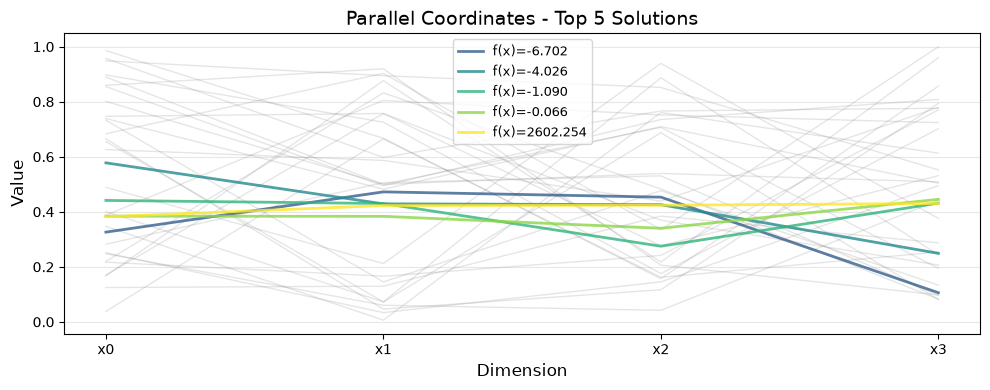

In [130]:
# Parallel coordinates: how does the new best point compare to other top solutions?
plot_parallel_coordinates(X, Y, n_best = 5)
plt.show()


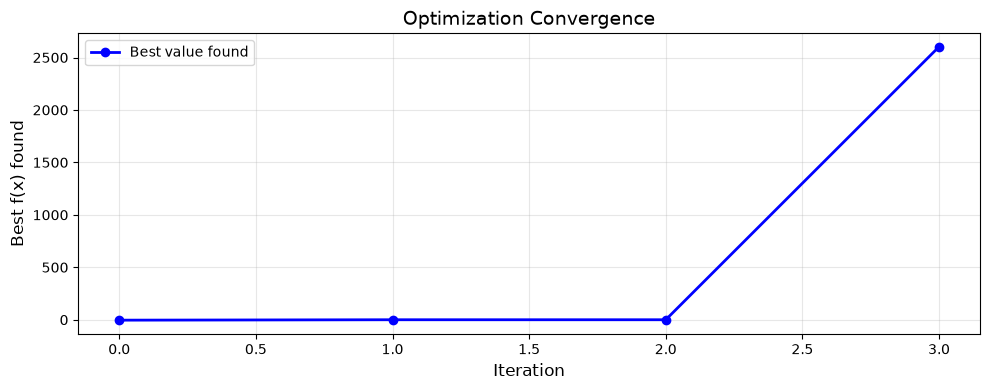

Convergence trace (best value found at each stage): [-4.025542281908162, -0.06634074624810848, -0.06634074624810848, np.float64(2602.2537934860957)]


In [134]:
# Convergence so far (initial best -> Week 1 result)
best_values  = [-4.025542281908162, -0.06634074624810848, -0.06634074624810848, Y.max()]
plot_convergence(range(len(best_values)), best_values)
plt.show()

print("Convergence trace (best value found at each stage):", best_values)